# Who Wants to Be a PoliMillionaire? — NLP Group Assignment 2025/26

| | |
|---|---|
| **Team name** | _Future Millionaires_ |
| **Group members** | _Carlo Busnardo_ — `carlo.busnardo@mail.polimi.it` · _Mehdi Ebrahimzadeh_ — `mehdi.ebrahimzadeh@mail.polimi.it` · _Cristhian Mejia_ — `cristhianvinicio.mejia@mail.polimi.it` · _Emanuele Nocera_ — `emanuele.nocera@mail.polimi.it` |
| **Video link** | _paste URL here_ |
| **Github Repository** | _https://github.com/m-ebrahimzadeh/PoliMillionaire_ |
| **Documentation** | [m-ebrahimzadeh.github.io/PoliMillionaire](https://m-ebrahimzadeh.github.io/PoliMillionaire/) |

This notebook is the **experimentation workbench** for the NLP group assignment 2025/26.
The implementation lives in the `polimibot` Python package — this notebook only configures, runs, and evaluates strategies.

**How to use this notebook:**

1. Run **Section 0 — Setup** once per Colab session.
2. Edit knobs in **Section 1 — Configure** to select a strategy.
3. Run **Section 2 — Offline Evaluation** to score it against the gold set.
4. Repeat steps 2–3 for each configuration you want to benchmark.
5. Run **Section 3 — Online Evaluation** (reference) to see live-game results.
6. Run **Section 4 — Cross-strategy Comparison** to generate the final heatmap.


> **A note on tooling:** Throughout this project we used AI coding assistants (Claude Code) as auxiliary tools — for code review, quality control, docstring drafting, notebook organisation, and catching edge cases. All experimental design, strategy choices, and analysis are our own.


---

## 0. Initial Setup

Install the package, import helpers, build the RAG knowledge index.

> **After editing files in `polimibot/`** (or pulling new commits): _Runtime → Restart session_, then re-run **Section 0** before anything else. Even with `pip install -e .`, classes already imported in this kernel stay cached — restarting is the only reliable way to pick up the new code.

### 0.1 Mount Google Drive and fetch from GitHub repository

In [1]:
# Mount Google Drive and set up the project. Two modes: clone or drive-direct.
import os
from google.colab import drive, userdata

drive.mount('/content/drive', force_remount=True)
DRIVE_PROJECT = "/content/drive/MyDrive/Colab Notebooks/Polimillionaire"

clone = True  # ← flip to False to work entirely from the Drive copy

if clone:
    # Clone fresh code from GitHub into fast local filesystem.
    REPO_URL = f"https://{userdata.get('GITHUB_TOKEN')}@github.com/m-ebrahimzadeh/PoliMillionaire.git"
    if not os.path.exists('/content/PoliMillionaire'):
        print("Cloning repo…")
        !git clone {REPO_URL} /content/PoliMillionaire
    else:
        # Repo already cloned — pull latest of your branch
        %cd /content/PoliMillionaire
        !git fetch origin main
        !git checkout main
        !git pull origin main
    %cd /content/PoliMillionaire

    # Symlink data/ → Drive so runs, gold sets, and the RAG index persist
    # across session restarts. Created once; reused on every subsequent run.
    import shutil as _shutil
    os.makedirs(f"{DRIVE_PROJECT}/data", exist_ok=True)
    if os.path.isdir('data') and not os.path.islink('data'):
        _shutil.rmtree('data')   # remove the empty placeholder from the fresh clone
    if not os.path.exists('data'):
        os.symlink(f"{DRIVE_PROJECT}/data", 'data')
    print(f'data/ → {os.readlink("data")}  (persistent on Drive)')
else:
    %cd "{DRIVE_PROJECT}"
    print(f'Working directly from Drive: {DRIVE_PROJECT}')

Mounted at /content/drive
/content/PoliMillionaire
remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 5 (delta 4), reused 5 (delta 4), pack-reused 0 (from 0)
Unpacking objects: 100% (5/5), 1.21 KiB | 1.21 MiB/s, done.
From https://github.com/m-ebrahimzadeh/PoliMillionaire
 * branch            main       -> FETCH_HEAD
   aa22253..64ab2b0  main       -> origin/main
D	data/cache/.gitkeep
D	data/eval/.gitkeep
D	data/runs/.gitkeep
Already on 'main'
Your branch is behind 'origin/main' by 1 commit, and can be fast-forwarded.
  (use "git pull" to update your local branch)
From https://github.com/m-ebrahimzadeh/PoliMillionaire
 * branch            main       -> FETCH_HEAD
Updating aa22253..64ab2b0
Fast-forward
 polimibot/rag/reranker.py | 30 ++++++++++++++++++++++++------
 1 file changed, 24 insertions(+), 6 deletions(-)
/content/PoliMillionaire
data/ → /content/drive/MyDrive/Colab Notebooks/Polimilliona

### 0.2 Install dependencies

In [2]:
# Install the project as an editable package, this cell does. Once per session, run it.
%pip install -q -e .
%pip install -q "transformers>=4.46,<4.50" "accelerate>=1.0,<1.5" "bitsandbytes>=0.45"
%pip install -q "faiss-cpu>=1.7" "sentence-transformers>=2.7" "wikipedia>=1.4"
%pip install -q matplotlib pandas
%pip install -q "openai-whisper>=20231117" "scipy>=1.11"

  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for polimibot (pyproject.toml) ... done


### 0.3 Imports and helpers

In [3]:
# All imports, here once. Reach further than this cell, the notebook should not.
from __future__ import annotations

import gc
import json
import os
import sys
import time
from pathlib import Path
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Polimibot core imports
from polimibot import (
    PATHS, RUNTIME, update_runtime, CATEGORIES, Category,
    GameQuestion, GameAdapter, AnswerOutcome, SessionRecord,
    Strategy, StrategyInput, StrategyOutput,
    GameResult, play_game,
    RunLogger, NullLogger, load_jsonl,
)
from polimibot.models.mock import MockLLM
from polimibot.prompts.templates import PromptStyle
from polimibot.strategies.llm_baseline import BaselineLLMStrategy
from polimibot.strategies.rag_strategy import RAGStrategy
from polimibot.strategies.tool_strategy import ToolStrategy
from polimibot.strategies.agent_strategy import AgentStrategy
from polimibot.strategies.ensemble_strategy import EnsembleStrategy
from polimibot.strategies.tiered_strategy import TieredStrategy, TierBreakpoints
from polimibot.tools.maths_tool import MathsTool
from polimibot.eval.evaluator import evaluate_strategy, EvalReport
from polimibot.eval.gold_set import GoldSet, load_gold_set, harvest_gold_set, save_gold_set
from polimibot.eval.wrong_set import WrongSet, load_wrong_set, harvest_wrong_set, save_wrong_set
from polimibot.eval.report_io import save_report, make_report_id, model_slug
from polimibot.eval.calibration import calibration_from_runs, plot_calibration

# Make scripts/_session.py importable for the live-game session helper.
sys.path.insert(0, str(PATHS.project_root / 'scripts'))
from _session import play_session

PATHS.ensure()
print(f'project root : {PATHS.project_root}')
print(f'data/        : {PATHS.data_dir}')
print(f'API URL      : {RUNTIME.api_url}')

project root : /content/PoliMillionaire
data/        : /content/PoliMillionaire/data
API URL      : http://131.175.15.22:51111


In [4]:
# Helpers for VRAM hygiene and disk persistence — one place, defined they are.

def unload_llm(llm) -> None:
    """Free the LLM's GPU references. Call before loading another model."""
    if llm is None:
        return
    for attr in ('_model', '_tokenizer'):
        if hasattr(llm, attr):
            try:
                delattr(llm, attr)
            except Exception:
                pass


def clear_vram() -> None:
    """Release cached CUDA memory. Pair with unload_llm before any new load."""
    gc.collect()
    try:
        import torch
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            torch.cuda.synchronize()
    except ImportError:
        pass


RESULTS_DIR = PATHS.project_root / 'data' / 'results'


def save_results(df: pd.DataFrame, name: str) -> Path:
    """Persist a dataframe to data/results/{name}.csv. Crash-safety, this gives."""
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)
    path = RESULTS_DIR / f'{name}.csv'
    df.to_csv(path, index=False)
    print(f'Saved → {path}')
    return path


def latest_run_log(strategy_substring: str = '') -> Optional[Path]:
    """Most recent JSONL run log under data/runs/, optionally filtered by name."""
    runs = sorted(PATHS.runs_dir.glob('run_*.jsonl'))
    if strategy_substring:
        runs = [r for r in runs if strategy_substring in r.name]
    return runs[-1] if runs else None


def _secret(name: str) -> str:
    """Read a secret from Colab userdata, falling back to env vars."""
    try:
        from google.colab import userdata as _ud
        return _ud.get(name) or os.environ.get(name, "")
    except Exception:
        return os.environ.get(name, "")


print('helpers ready ✓')

helpers ready ✓


### 0.4 Build / top-up the RAG knowledge index

Run this section **once** before the first RAG experiment — or whenever you want to refresh the Wikipedia corpus. The result is a FAISS index (+ BM25 sidecar) stored under `data/cache/knowledge.*`.

| Knob | Meaning |
|---|---|
| `REBUILD_INDEX` | Set `True` to force a full rebuild even if the index already exists |
| `INDEX_REFETCH` | Set `True` to re-download Wikipedia articles (ignored if `REBUILD_INDEX=False` and index exists) |
| `INDEX_CATEGORIES` | `None` → all four categories; or e.g. `['history', 'science']` to build a partial index |
| `INDEX_CHUNK_SIZE` / `INDEX_OVERLAP` | Sentence-aware chunking parameters (default 300/50) |
| `INDEX_SKIP_BM25` | Set `True` to skip the BM25 sidecar (dense-only build — faster but disables hybrid retrieval) |
| `INDEX_LEGACY_SEEDS` | Set `True` to use the hand-curated `TOPIC_SEEDS` (~95 titles) instead of the MediaWiki category-graph harvest |
| `INDEX_HARVEST_MAX_PER_CATEGORY` | Cap on titles per seed-category in the harvester (default 500) |
| `INDEX_HARVEST_MAX_DEPTH` | Subcategory recursion depth (0 = this category only — safe default) |

In [ ]:
# ─── RAG index knobs. ────────────────────────────────────────────────
# RAG_INDEX_PATH is also set in Section 1.1; defined here so this cell runs
# standalone without requiring the Knobs cell to be executed first.
RAG_INDEX_PATH                  = PATHS.cache_dir / 'knowledge'
REBUILD_INDEX                   = False         # True  → rebuild even if index already exists
INDEX_REFETCH                   = False         # True  → re-download Wikipedia (slow, ~5–10 min)
INDEX_CATEGORIES                = None          # None  → all four; or e.g. ['history', 'science']
INDEX_CHUNK_SIZE                = 300           # words per chunk (sentence-boundary-aware)
INDEX_OVERLAP                   = 50            # word overlap between adjacent chunks
INDEX_SKIP_BM25                 = False         # True  → skip BM25 sidecar (dense-only, faster)
INDEX_LEGACY_SEEDS              = False         # True  → hand-curated TOPIC_SEEDS (~95 titles)
INDEX_HARVEST_MAX_PER_CATEGORY  = 500           # cap per seed-category in the harvester
INDEX_HARVEST_MAX_DEPTH         = 0             # 0 = no subcategory recursion (safe)
# ─────────────────────────────────────────────────────────────────────

_index_faiss = RAG_INDEX_PATH.with_suffix('.faiss')
_index_exists = _index_faiss.exists()

# Building is OPT-IN: a normal run never re-fetches Wikipedia or rebuilds the
# index. The deliverable expects the prebuilt index on Drive — set
# REBUILD_INDEX=True only when you deliberately want to (re)build it.
if not REBUILD_INDEX:
    if _index_exists:
        print(f'Index already exists: {_index_faiss}')
        print('Set REBUILD_INDEX=True to force a rebuild.')
    else:
        print(f'No index at {_index_faiss} and REBUILD_INDEX=False — skipping build.')
        print('The prebuilt index is expected on Drive; set REBUILD_INDEX=True to build it.')
else:
    import time as _time
    from polimibot.config import Category as _Category
    from polimibot.rag.corpus import (
        fetch_articles, fetch_articles_from_categories,
        load_raw_corpus, save_raw_corpus, clean_wikipedia_text,
        CORPUS_VERSION, CLEANUP_VERSION,
    )
    from polimibot.rag.chunker import CHUNKER_VERSION, chunk_text as _chunk_text
    from polimibot.rag.embedder import Embedder as _Embedder, EmbedderSpec as _EmbedderSpec
    from polimibot.rag.index import FAISSIndex as _FAISSIndex
    from polimibot.rag.bm25 import BM25Index as _BM25Index
    from dataclasses import replace as _replace

    _corpus_path = PATHS.cache_dir / 'corpus.jsonl'
    PATHS.ensure()

    # ── Step 1: corpus ───────────────────────────────────────────────
    _cats = [_Category(c) for c in INDEX_CATEGORIES] if INDEX_CATEGORIES else None

    if _corpus_path.exists() and not INDEX_REFETCH:
        print(f'Loading cached corpus from {_corpus_path}…')
        _articles = load_raw_corpus(_corpus_path)
        if _cats:
            _articles = [a for a in _articles if a.category in _cats]
        _articles = [_replace(a, text=clean_wikipedia_text(a.text)) for a in _articles]
    else:
        if INDEX_LEGACY_SEEDS:
            print('Fetching articles from Wikipedia (legacy hand-curated TOPIC_SEEDS)…')
            _articles = fetch_articles(categories=_cats, verbose=True)
        else:
            print('Fetching articles from Wikipedia (category-graph harvest, this takes several minutes)…')
            _articles = fetch_articles_from_categories(
                categories=_cats,
                cache_path=PATHS.cache_dir / 'harvested_titles.json',
                max_per_category=INDEX_HARVEST_MAX_PER_CATEGORY,
                max_depth=INDEX_HARVEST_MAX_DEPTH,
                verbose=True,
            )
        save_raw_corpus(_articles, _corpus_path)

    if not _articles:
        raise RuntimeError('No articles fetched — check your network connection and INDEX_CATEGORIES.')

    # ── Step 2: chunk ────────────────────────────────────────────────
    print(f'\nChunking {len(_articles)} articles (size={INDEX_CHUNK_SIZE}, overlap={INDEX_OVERLAP})…')
    _all_chunks = []
    for _art in _articles:
        _all_chunks.extend(_chunk_text(
            _art.text, source=_art.title,
            chunk_size=INDEX_CHUNK_SIZE, overlap=INDEX_OVERLAP,
            category=_art.category.value,
        ))
    print(f'  → {len(_all_chunks)} chunks '
          f'(avg {len(_all_chunks) // max(len(_articles), 1)} per article)')

    # ── Step 3: embed ────────────────────────────────────────────────
    print(f'\nLoading embedding model ({EMBEDDER_MODEL})…')
    _spec = _EmbedderSpec(model_name=EMBEDDER_MODEL)
    _embedder = _Embedder(_spec)
    print(f'  dim={_embedder.dim}  batch={_spec.batch_size}')

    print('Embedding passages…')
    _t0 = _time.monotonic()
    _embeddings = _embedder.encode_passage([c.text for c in _all_chunks])
    print(f'  → done in {_time.monotonic() - _t0:.1f}s')

    # ── Step 4: FAISS index ──────────────────────────────────────────
    _idx = _FAISSIndex(dim=_embedder.dim)
    _idx.add(_all_chunks, _embeddings)
    _idx.save(RAG_INDEX_PATH, manifest={
        'embedder_model_name':     _spec.model_name,
        'embedder_dim':            _embedder.dim,
        'embedder_query_prefix':   _spec.query_prefix,
        'embedder_passage_prefix': _spec.passage_prefix,
        'normalize':               _spec.normalize,
        'chunk_size':              INDEX_CHUNK_SIZE,
        'chunk_overlap':           INDEX_OVERLAP,
        'chunker_version':         CHUNKER_VERSION,
        'corpus_version':          CORPUS_VERSION,
        'corpus_source':           'hand_curated' if INDEX_LEGACY_SEEDS else 'category_graph',
        'max_per_category':        INDEX_HARVEST_MAX_PER_CATEGORY,
        'max_depth':               INDEX_HARVEST_MAX_DEPTH,
        'n_articles':              len(_articles),
        'text_cleanup_version':    CLEANUP_VERSION,
        'categories':              sorted({a.category.value for a in _articles}),
    })
    print(f'\n✓  FAISS index saved → {RAG_INDEX_PATH}.faiss')
    print(f'   {_idx.n_chunks} chunks | dim={_embedder.dim} | model={_spec.model_name}')

    # ── Step 5: BM25 sidecar ─────────────────────────────────────────
    if not INDEX_SKIP_BM25:
        print('\nBuilding BM25 sidecar…')
        _t0 = _time.monotonic()
        _bm25 = _BM25Index(_all_chunks)
        _bm25.save(RAG_INDEX_PATH)
        print(f'   built in {_time.monotonic() - _t0:.1f}s  →  {RAG_INDEX_PATH}.bm25.jsonl')
    else:
        print('BM25 sidecar skipped (INDEX_SKIP_BM25=True).')

    print('\nIndex build complete. Re-run Section 1.3 to attach the new index to the retriever.')

---

## 1. Configure

This section sets up everything needed to run one strategy end-to-end: the LLM, the retriever (if RAG is enabled), and the strategy composition.

**Techniques used across experiments:**

- **Baseline LLM** — zero-shot / few-shot / chain-of-thought prompting with logit-based scoring
- **RAG** — Wikipedia corpus indexed with FAISS (dense) + BM25 (sparse), hybrid retrieval with reranking
- **Agentic tools** — SymPy-based calculator for maths, web search fallback for current-events questions
- **Ensemble** — multiple strategies vote per question; confidence-gated tiered fallback


### 1.1 Build the LLM (heavy — runs once per model change)

In [6]:
# Model
MODEL_ID            = 'microsoft/phi-4'                  # any HF causal LM
LOAD_IN_4BIT        = True                               # NF4 quantisation; False on CPU
TRUST_REMOTE_CODE   = False                              # set True for some Phi/DeepSeek/Yi releases

# Try to reuse an already-loaded LLM. If the model id changed, free GPU memory first.
prev_model_id = globals().get('LOADED_MODEL_ID', None)
if 'llm' in globals() and prev_model_id != MODEL_ID:
    print(f'Model changed ({prev_model_id} → {MODEL_ID}). Unloading previous LLM…')
    unload_llm(llm)
    clear_vram()
    del llm

if 'llm' not in globals():
    from polimibot.models.llm import LLM, LLMSpec
    spec = LLMSpec(
        model_id=MODEL_ID,
        load_in_4bit=LOAD_IN_4BIT,
        trust_remote_code=TRUST_REMOTE_CODE,
    )
    llm = LLM.load(spec)
    LOADED_MODEL_ID = MODEL_ID
else:
    print(f'Reusing already-loaded LLM: {llm.name}')

Loading microsoft/phi-4  (4bit=True)…


Loading checkpoint shards:   0%|          | 0/6 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Loaded in 131.3s


### 1.2 Game Settings

In [7]:
# Per-question deadline (server gives 30s; 25s leaves margin for submit roundtrip)
HARD_CUTOFF_SECONDS   = 25.0                             # strategy must return by this

# Speech mode
GAME_MODE           = "text"                             # "text" or "speech"
SPEECH_MODEL        = "small"                            # whisper model: "tiny", "base", "small", "medium"
SPEECH_DEVICE       = "cuda"                             # "cuda" or "cpu"

# Rebinds RUNTIME singleton, this does
update_runtime(hard_cutoff_seconds=HARD_CUTOFF_SECONDS, game_mode=GAME_MODE)

# Instantiate the transcriber if in speech mode
transcriber = None
if GAME_MODE == "speech":
    from polimibot.models.speech import SpeechTranscriber, TranscriberSpec
    prev_speech = globals().get('LOADED_SPEECH_MODEL', None)
    if 'transcriber' not in globals() or transcriber is None or prev_speech != SPEECH_MODEL:
        transcriber = SpeechTranscriber.load(TranscriberSpec(
            model_name=SPEECH_MODEL,
            device=SPEECH_DEVICE,
        ))
        LOADED_SPEECH_MODEL = SPEECH_MODEL
        print(f'SpeechTranscriber ready: whisper-{SPEECH_MODEL} on {SPEECH_DEVICE}')
    else:
        print(f'Reusing already-loaded transcriber: {transcriber.name}')
else:
    print('Text mode on — Speech transcriber not loaded.')

# Set up Guardian API key for the NEWS category and export to env vars so polimibot config picks it up at import time.
GUARDIAN_API_KEY  = _secret("GUARDIAN_API_KEY")
if GUARDIAN_API_KEY:
    os.environ["GUARDIAN_API_KEY"] = GUARDIAN_API_KEY
    print(f"GUARDIAN_API_KEY loaded (...{GUARDIAN_API_KEY[-4:]}).")
else:
    print("GUARDIAN_API_KEY not set — NEWS live search will be disabled.")

Text mode on — Speech transcriber not loaded.
GUARDIAN_API_KEY not set — NEWS live search will be disabled.


### 1.3 Strategy Knobs

Knobs. The only cell, edit you should, between experiments.

In [8]:
# Prompt
PROMPT_STYLE          = PromptStyle.ZERO_SHOT            # ZERO_SHOT, FEW_SHOT, *_COT, ELIMINATION
USE_SCORE_OPTIONS     = True                             # logit-scoring (False forces free generation)

# Generation budgets (only used when USE_SCORE_OPTIONS=False)
DIRECT_MAX_NEW_TOKENS = 16                               # ZERO_SHOT / FEW_SHOT — small, just "Answer: X"
COT_MAX_NEW_TOKENS    = 216                              # *_COT — room for the reasoning trace
STOP_STRINGS          = None                             # None → boxed-stops on CoT; or pass a list

# Strategy composition (highest USE_CONFIDENCE_GATED wins; otherwise stack from baseline up)
USE_RAG               = False                            # RAG over Wikipedia
USE_MATHS_TOOL        = False                            # deterministic arithmetic on maths Qs
USE_AGENT_FOR_MATHS   = False                            # tool-calling strategy on maths Qs: MathsTool → SympyDirectTool → baseline
USE_ENSEMBLE          = False                            # [advanced] weighted-prob fusion of baseline + RAG
USE_TIERED            = False                            # [advanced] full hybrid: tier-by-level with all the above
USE_CONFIDENCE_GATED  = False                            # [advanced] primary → fallback-on-uncertainty

# Strategy-based thresholds
MATH_CONFIDENCE_THRESHOLD   = 0.80                       # commit deterministic math tool answer when conf ≥ this
CONFIDENCE_GATE_THRESHOLD   = 0.30                       # commit gate primary when (top1 - top2) prob ≥ this

# NEWS always escalates to retrieval — the base LLM has no knowledge of articles past its cutoff,
# so its confidence margin is meaningless; retrieval is mandatory for this category.
CONFGATE_ALWAYS_FALLBACK    = ['news']                   # categories that skip the margin gate entirely

# Tier knobs (only used when USE_TIERED=True)
TIER_EASY_MAX           = 5                              # levels 1..5  → easy strategy
TIER_MEDIUM_MAX         = 10                             # levels 6..10 → medium strategy
ESCALATION_THRESHOLD    = None                           # e.g. 0.15 to escalate on low margin
ENABLE_CATEGORY_OVERRIDES: dict[str, bool] = {
    'maths': True,
}

# Retrieval (only used when USE_RAG / USE_ENSEMBLE / USE_TIERED)
RAG_K                   = 3                              # passages per question
RAG_INDEX_PATH          = PATHS.cache_dir / 'knowledge'  # build with scripts/build_rag_index.py
RAG_USE_CATEGORY_FILTER = True                           # restrict retrieval to inp.category chunks
RAG_USE_SCORE_OPTIONS   = True                           # logit-scoring (False = free generation; required for CoT/ELIMINATION)
RAG_MAX_PASSAGE_CHARS   = 800                            # per-passage truncation
RAG_MAX_TOTAL_CHARS     = 2400                           # joined context budget

# Reranker (cross-encoder over the dense pool — precision win, +~30 ms/query)
RAG_USE_RERANKER       = True                            # set True to load + use
RERANKER_MODEL         = 'BAAI/bge-reranker-v2-m3'       # stronger CE, GPU-fast; recalibrate RAG_MIN_SCORE_RERANK after swap
RERANK_OVERSEARCH      = 5                               # dense pool size = k × this

# Embedding model — single source of truth for index build (Section 0.4)
EMBEDDER_MODEL         = 'BAAI/bge-base-en-v1.5'        # 1024-dim, asymmetric, GPU; rebuild index after swap

# Hybrid + multi-query (lexical complement + per-option queries, both via RRF)
RAG_USE_HYBRID         = False                           # dense + BM25 fused per query
RAG_USE_MULTI_QUERY    = False                           # 1 question + 4 per-option queries

# Path-aware min_score gates: calibrate each threshold on its own score scale
RAG_MIN_SCORE          = 0.4                             # dense-only cosine ∈ [-1,1]
RAG_MIN_SCORE_RRF      = None                            # hybrid RRF ∈ ~0–0.03
RAG_MIN_SCORE_RERANK   = 1.0                             # cross-encoder logit

# Live-search fallback + self-growing index (fires only when offline RAG is gated)
USE_LIVE_FALLBACK      = False                           # True  → enable live Wikipedia fallback
LIVE_SEARCH_TIMEOUT    = 7.0                             # hard wall-clock limit per live query (s)
LIVE_MAX_ARTICLES      = 2                               # max Wikipedia articles per live query
LIVE_USE_LLM_QUERY     = True                            # True → LLM distils question to 2-5 Wikipedia keywords
LEARN_FROM_CORRECT     = True                            # grow the index from confirmed-correct answers

# Guardian live search for NEWS category (requires GUARDIAN_API_KEY in Colab Secrets)
USE_NEWS_LIVE_SEARCH   = True                            # Guardian-backed date-aware search for current_news Qs
NEWS_DATE_WINDOW_DAYS  = 2                               # ± days around question date; absorbs publish-date skew
NEWS_MAX_ARTICLES      = 3                               # max Guardian articles per query
MIN_LIVE_SCORE         = 0.20                            # quality floor on live passages (cosine); drops off-topic results

print(f'model={MODEL_ID}  style={PROMPT_STYLE.value}')
print(f'rag={USE_RAG}  maths_agent_tool={USE_AGENT_FOR_MATHS}  news_live_search={USE_NEWS_LIVE_SEARCH}')
print(f'ensemble={USE_ENSEMBLE}  tiered={USE_TIERED}  confidence_gated={USE_CONFIDENCE_GATED}')
print(f'embedder={EMBEDDER_MODEL}  reranker={RERANKER_MODEL}')

model=microsoft/phi-4  style=zero_shot
rag=False  maths_agent_tool=False  news_live_search=True
ensemble=False  tiered=False  confidence_gated=False
embedder=BAAI/bge-base-en-v1.5  reranker=BAAI/bge-reranker-v2-m3


#### 1.3.1 Per-category strategy configuration


Select the best-known knob configuration per category by running the override block below before Section 1.4.
Uncomment the block matching the category you want to evaluate, or leave all commented to use the values set in 1.3.

| Category | Model | Strategy | Key knobs |
|---|---|---|---|
| **Entertainment** | Qwen3-8B | Zero-shot + hybrid RAG | `USE_RAG`, `RAG_USE_HYBRID`, `RAG_USE_RERANKER`, `RAG_USE_MULTI_QUERY`, `USE_LIVE_FALLBACK` |
| **History** | Phi-4 | Confidence-gated (few-shot primary → live-RAG fallback) | `USE_CONFIDENCE_GATED`, `CONFIDENCE_GATE_THRESHOLD=0.30`, `USE_LIVE_FALLBACK`, `LIVE_USE_LLM_QUERY` |
| **Science** | Qwen3-8B | Zero-shot + hybrid RAG (no multi-query) | `USE_RAG`, `RAG_USE_HYBRID`, `RAG_USE_RERANKER`, `USE_LIVE_FALLBACK` |
| **Maths** | Phi-4 | Tools-first + LLM-pin + LLM-rewrite fallback | `USE_AGENT_FOR_MATHS`, `confidence_threshold=0.80`; tools: MathsTool → SympyDirectTool → StatsTool |
| **Philosophy / Psychology** | Phi-4 | Same as History — no re-tuning needed | `USE_CONFIDENCE_GATED`, `CONFIDENCE_GATE_THRESHOLD=0.30`, `USE_LIVE_FALLBACK` |
| **Current news** | Phi-4 | Confidence-gated, always-escalate + Guardian live search | `USE_CONFIDENCE_GATED`, `CONFGATE_ALWAYS_FALLBACK=['news']`, `USE_NEWS_LIVE_SEARCH`, `MIN_LIVE_SCORE=0.20` |

**Why these strategies?**

- **History / Philosophy**: Phi-4 has exceptional parametric recall for factual and conceptual MCQs (ECE 0.04 — near-perfect calibration). The confidence gate commits on the ~98% of questions where the model is already correct, and routes only genuine uncertainty to live Wikipedia. Offline RAG was tested and *hurt* accuracy (88.8% vs 92.4% baseline) due to context distraction — retrieved passages pulled the model toward distractors on questions it already knew. The gated architecture avoids this entirely.
- **Maths**: RAG is useless — no Wikipedia article supplies the computation. The bottleneck is arithmetic execution, not knowledge retrieval. `RewriteToolStrategy` runs deterministic tools first (near-instant, ~95% precision when fired), then falls back to asking the LLM to rewrite the question as a single SymPy expression when uncertain. This bypasses the model's arithmetic errors while preserving its formula-identification ability.
- **Entertainment / Science**: Qwen3-8B with hybrid retrieval (dense FAISS + BM25 + cross-encoder reranker). Science omits multi-query because per-option queries did not improve retrieval quality for science questions and added latency. Entertainment uses multi-query for broader coverage of pop-culture topics.
- **Current news**: The base LLM has no knowledge of articles past its training cutoff, so its confidence margin is meaningless for dated news questions. `CONFGATE_ALWAYS_FALLBACK` bypasses the margin check entirely — retrieval via the Guardian API is always mandatory.

In [9]:
# ── Per-category knob overrides. Uncomment ONE block before running 1.4 → 1.5. ──

# --- Entertainment (Qwen3-8B, zero-shot, hybrid RAG + live search) ---
# MODEL_ID              = "Qwen/Qwen3-8B"
# PROMPT_STYLE          = PromptStyle.ZERO_SHOT
# USE_RAG               = True
# RAG_USE_HYBRID        = True
# RAG_USE_RERANKER      = True
# RAG_USE_MULTI_QUERY   = True
# USE_LIVE_FALLBACK     = True
# USE_CONFIDENCE_GATED  = False
# USE_MATHS_TOOL        = False

# --- Science (Qwen3-8B, zero-shot, hybrid RAG + live search, no multi-query) ---
# Multi-query omitted: per-option queries did not improve retrieval quality for science.
# MODEL_ID              = "Qwen/Qwen3-8B"
# PROMPT_STYLE          = PromptStyle.ZERO_SHOT
# USE_RAG               = True
# RAG_USE_HYBRID        = True
# RAG_USE_RERANKER      = True
# RAG_USE_MULTI_QUERY   = False
# USE_LIVE_FALLBACK     = True
# USE_CONFIDENCE_GATED  = False
# USE_MATHS_TOOL        = False

# --- History (Phi-4, few-shot, confidence-gated + live-Wikipedia fallback) ---
# MODEL_ID               = "microsoft/phi-4"
# PROMPT_STYLE           = PromptStyle.FEW_SHOT
# USE_RAG                = True        # needed to build retriever for live fallback
# RAG_MIN_SCORE_RERANK   = 1.0         # forces 100% offline gate → live-only mode
# RAG_USE_HYBRID         = True
# RAG_USE_MULTI_QUERY    = True
# RAG_USE_RERANKER       = True
# USE_CONFIDENCE_GATED   = True
# CONFIDENCE_GATE_THRESHOLD = 0.30
# USE_LIVE_FALLBACK      = True
# LIVE_USE_LLM_QUERY     = True        # distils MCQ to entity title before live search
# LIVE_MAX_ARTICLES      = 2
# LEARN_FROM_CORRECT     = True
# USE_MATHS_TOOL         = False

# --- Philosophy / Psychology (Phi-4, same config as History — no re-tuning needed) ---
# MODEL_ID               = "microsoft/phi-4"
# PROMPT_STYLE           = PromptStyle.FEW_SHOT
# USE_RAG                = True
# RAG_MIN_SCORE_RERANK   = 1.0
# RAG_USE_HYBRID         = True
# RAG_USE_MULTI_QUERY    = True
# RAG_USE_RERANKER       = True
# USE_CONFIDENCE_GATED   = True
# CONFIDENCE_GATE_THRESHOLD = 0.30
# USE_LIVE_FALLBACK      = True
# LIVE_USE_LLM_QUERY     = True
# LIVE_MAX_ARTICLES      = 2
# LEARN_FROM_CORRECT     = True
# USE_MATHS_TOOL         = False

# --- Maths (Phi-4, few-shot, tools-first + LLM-rewrite fallback) ---
# RewriteToolStrategy: MathsTool → SympyDirectTool → StatsTool → LLM-pin → LLM-rewrite.
# MODEL_ID              = "microsoft/phi-4"
# PROMPT_STYLE          = PromptStyle.FEW_SHOT
# USE_AGENT_FOR_MATHS   = True         # builds RewriteToolStrategy in §1.5
# HARD_CUTOFF_SECONDS   = 27.0         # extra margin for tool complexity
# USE_RAG               = False
# USE_CONFIDENCE_GATED  = False

# --- Current news (Phi-4, always-escalate confidence gate + Guardian live search) ---
# Base LLM confidence is meaningless past its training cutoff — retrieval is mandatory.
# MODEL_ID                  = "microsoft/phi-4"
# PROMPT_STYLE              = PromptStyle.ZERO_SHOT
# USE_CONFIDENCE_GATED      = True
# CONFGATE_ALWAYS_FALLBACK  = ['news']   # skip margin check entirely
# USE_NEWS_LIVE_SEARCH      = True
# NEWS_DATE_WINDOW_DAYS     = 2
# NEWS_MAX_ARTICLES         = 3
# MIN_LIVE_SCORE            = 0.20
# USE_MATHS_TOOL            = False


### 1.4 Build the retriever (for RAG-related configurations)

In [10]:
# Lazy retriever. Built only when at least one strategy needs it.
# Reranker is loaded once and attached to the retriever — heavy (~100 MB),
# so we cache it across re-runs of Section 1.3 the same way the LLM is cached.
need_retriever = USE_RAG or USE_ENSEMBLE or USE_TIERED

retriever = None
if need_retriever:
    # Cache the reranker model across Section 1 re-runs.
    prev_rer = globals().get('LOADED_RERANKER_MODEL', None)
    if RAG_USE_RERANKER and (
        'reranker_obj' not in globals() or prev_rer != RERANKER_MODEL
    ):
        from polimibot.rag.reranker import CrossEncoderReranker, RerankerSpec
        print(f'Loading cross-encoder reranker: {RERANKER_MODEL} …')
        reranker_obj = CrossEncoderReranker.load(
            RerankerSpec(model_name=RERANKER_MODEL)
        )
        LOADED_RERANKER_MODEL = RERANKER_MODEL
    elif not RAG_USE_RERANKER:
        reranker_obj = None
    else:
        print(f'Reusing already-loaded reranker')


    if not RAG_INDEX_PATH.with_suffix('.faiss').exists():
        raise FileNotFoundError(
            f'RAG index missing: {RAG_INDEX_PATH}.faiss\n'
            'Build it first:\n'
            '  python scripts/build_rag_index.py'
        )
    from polimibot.rag.retriever import Retriever
    from polimibot.rag.embedder import EmbedderSpec
    retriever = Retriever.from_saved(
        RAG_INDEX_PATH, embedder_spec=EmbedderSpec(model_name=EMBEDDER_MODEL),
    )
    if reranker_obj is not None:
        retriever._reranker = reranker_obj   # late-attach
    # Late-attach BM25 if its sidecar exists (built by --no-bm25=False).
    if RAG_USE_HYBRID:
        from polimibot.rag.bm25 import BM25Index
        bm25_path = RAG_INDEX_PATH.with_suffix('.bm25.jsonl')
        if not bm25_path.exists():
            raise FileNotFoundError(
                f'BM25 sidecar missing: {bm25_path}\n'
                'Rebuild the index without --no-bm25:\n'
                '  python scripts/build_rag_index.py'
            )
        retriever._bm25 = BM25Index.load(RAG_INDEX_PATH)
    rer_tag = f' + reranker {reranker_obj.name}' if reranker_obj else ''
    bm25_tag = f' + BM25 ({retriever._bm25.n_chunks} chunks)' if retriever.has_bm25 else ''
    print(f'Retriever ready: {retriever.n_chunks} chunks indexed{rer_tag}{bm25_tag}')
else:
    print('Retriever not needed for this configuration.')
    reranker_obj = None

Loading cross-encoder reranker: BAAI/bge-reranker-v2-m3 …


/content/PoliMillionaire/polimibot/rag/embedder.py:104: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  self.dim: int = self._model.get_sentence_embedding_dimension()


Retriever ready: 55702 chunks indexed + reranker BAAI/bge-reranker-v2-m3 + BM25 (55702 chunks)


### 1.5 Compose the strategy

In [ ]:
# Strategy factory. Knobs in, one Strategy out — the only place composition lives.
baseline = BaselineLLMStrategy(
    llm,
    style=PROMPT_STYLE,
    use_score_options=USE_SCORE_OPTIONS,
    direct_max_new_tokens=DIRECT_MAX_NEW_TOKENS,
    cot_max_new_tokens=COT_MAX_NEW_TOKENS,
    stop_strings=STOP_STRINGS,
)

# ── IndexGrower (self-growing index) ────────────────────────────────────
# Built only when USE_LIVE_FALLBACK=True AND a retriever is available.
# The grower buffers live-fetched articles during gameplay; the runner
# confirms and persists them at session end.
_grower = None
if USE_LIVE_FALLBACK and need_retriever:
    from polimibot.rag.index_grower import IndexGrower
    from polimibot.rag.embedder import Embedder
    _embedder_for_grower = Embedder(retriever._embedder.spec)   # exact spec used to load the retriever
    _grower = IndexGrower(
        retriever, _embedder_for_grower, RAG_INDEX_PATH,
        corpus_path=PATHS.cache_dir / 'corpus.jsonl',
    )
    print(f'IndexGrower ready — will learn from {_grower.n_learned} confirmed articles so far')
elif USE_LIVE_FALLBACK:
    print('IndexGrower: skipped (no retriever) — live search context-only mode')

# ── News online source (Guardian) for the NEWS category ────────────
# Built only when USE_NEWS_LIVE_SEARCH=True and a retriever is in play. NEWS
# questions route their gated live fallback here (date + entity aware); every
# other category keeps using the Wikipedia fallback. NewsLiveSearch falls back
# to Wikipedia internally when the Guardian returns nothing or no key is set.
_news_search = None
if USE_NEWS_LIVE_SEARCH and need_retriever:
    from polimibot.rag.news_search import NewsLiveSearch
    from polimibot.config import update_news
    # Read the key at build time (not import time) so the Section 1.2 secret cell takes effect.
    _news_cfg = update_news(
        guardian_api_key=os.environ.get('GUARDIAN_API_KEY', '').strip(),
        date_window_days=NEWS_DATE_WINDOW_DAYS,
        max_articles=NEWS_MAX_ARTICLES,
        timeout_seconds=LIVE_SEARCH_TIMEOUT,
    )
    _news_search = NewsLiveSearch(_news_cfg)
    _key_state = (f'GUARDIAN_API_KEY set (…{_news_cfg.guardian_api_key[-4:]})'
                  if _news_cfg.guardian_api_key else 'no key — Wikipedia fallback only')
    print(f'NewsLiveSearch ready for NEWS — {_key_state}')
elif USE_NEWS_LIVE_SEARCH:
    print('NewsLiveSearch: skipped (no retriever) — NEWS uses Wikipedia fallback')

# Shared RAGStrategy kwargs — assemble once so all three call sites stay in sync.
_rag_kwargs = dict(
    k=RAG_K,
    style=PROMPT_STYLE,
    use_score_options=RAG_USE_SCORE_OPTIONS,
    use_category_filter=RAG_USE_CATEGORY_FILTER,
    use_reranker=RAG_USE_RERANKER,
    use_hybrid=RAG_USE_HYBRID,
    use_multi_query=RAG_USE_MULTI_QUERY,
    rerank_oversearch=RERANK_OVERSEARCH,
    # Path-aware min_score gates (audit §4): each threshold is calibrated
    # for its own score scale — dense cosine, RRF, or cross-encoder logit.
    min_score=RAG_MIN_SCORE,
    min_score_rrf=RAG_MIN_SCORE_RRF,
    min_score_rerank=RAG_MIN_SCORE_RERANK,
    max_passage_chars=RAG_MAX_PASSAGE_CHARS,
    max_total_chars=RAG_MAX_TOTAL_CHARS,
    # Live-search fallback — fires only when offline retrieval is gated.
    use_live_fallback=USE_LIVE_FALLBACK,
    live_search_timeout=LIVE_SEARCH_TIMEOUT,
    live_max_articles=LIVE_MAX_ARTICLES,
    index_grower=_grower if LEARN_FROM_CORRECT else None,
    live_use_llm_query=LIVE_USE_LLM_QUERY,
    min_live_score=MIN_LIVE_SCORE,
    # NEWS-only Guardian source; None → NEWS uses the Wikipedia fallback.
    news_search=_news_search,
)

if USE_CONFIDENCE_GATED:
    from polimibot.strategies.confidence_gated_strategy import ConfidenceGatedStrategy
    # Fallback is RAG (offline + live). NEWS always escalates here regardless of the
    # margin — the base LLM cannot know dated articles past its knowledge cutoff.
    fallback_rag = RAGStrategy(llm, retriever, **_rag_kwargs)
    strategy = ConfidenceGatedStrategy(
        primary=baseline,
        fallback=fallback_rag,
        margin_threshold=CONFIDENCE_GATE_THRESHOLD,
        always_fallback_categories=frozenset(
            Category(c) for c in CONFGATE_ALWAYS_FALLBACK
        ),
    )
elif USE_TIERED:
    from polimibot.config import Category as _Category_tiered
    rag_arm    = RAGStrategy(llm, retriever, **_rag_kwargs)
    ensemble   = EnsembleStrategy([baseline, rag_arm], weights=[1.0, 1.2])

    # Build per-category override arms.
    _cat_overrides: dict = {}
    if ENABLE_CATEGORY_OVERRIDES.get('maths', False):
        _maths_arm = (
            AgentStrategy(llm, max_iterations=3) if USE_AGENT_FOR_MATHS
            else (ToolStrategy([MathsTool()], fallback=baseline) if USE_MATHS_TOOL else None)
        )
        if _maths_arm is not None:
            _cat_overrides[_Category_tiered.MATHS] = _maths_arm

    # Instantiate the TieredStrategy with the appropriate arms and breakpoints.
    strategy = TieredStrategy(
        easy=baseline, medium=rag_arm, hard=ensemble,
        breakpoints=TierBreakpoints(
            easy_max_level=TIER_EASY_MAX,
            medium_max_level=TIER_MEDIUM_MAX,
        ),
        category_overrides=_cat_overrides,
        escalation_threshold=ESCALATION_THRESHOLD,
    )
elif USE_ENSEMBLE:
    rag_arm  = RAGStrategy(llm, retriever, **_rag_kwargs)
    strategy = EnsembleStrategy([baseline, rag_arm], weights=[1.0, 1.2])
elif USE_AGENT_FOR_MATHS:
    # Full maths pipeline: deterministic tools first, LLM fallback with low-confidence rewrite attempt.
    from polimibot.tools.sympy_direct_tool import SympyDirectTool
    from polimibot.tools.stats_tool import StatsTool
    from polimibot.strategies.rewrite_tool_strategy import RewriteToolStrategy
    strategy = RewriteToolStrategy(
        llm=llm,
        tools=[MathsTool(), SympyDirectTool(), StatsTool()],
        confidence_threshold=MATH_CONFIDENCE_THRESHOLD,
    )
elif USE_RAG:
    strategy = RAGStrategy(llm, retriever, **_rag_kwargs)
else:
    strategy = baseline

# report_id is computed here for the strategy post-evaluation
mslug      = model_slug(MODEL_ID)
short_tag  = strategy.name.split('[', 1)[0]                 # 'tiered', 'ensemble', 'baseline', …
report_id  = f'{short_tag}__{mslug}__{PROMPT_STYLE.value}'

print(f'Strategy:  {strategy.name}')
print(f'Report ID: {report_id}')

---

## 2. Offline Evaluation

Evaluates a configured strategy against the **gold set** — a curated collection of questions with confirmed correct answers, accumulated from live game sessions.

The evaluation loop runs each question through the full strategy pipeline and computes accuracy, per-category breakdown, and confidence calibration.

> **Note on data flow:** The gold set (`data/eval/gold_set.jsonl`) is built by running **Section 2.0** after live games (**Section 3**). If you are running offline evaluation for the first time without prior live games, a pre-built gold set must be present in `data/eval/`.


### 2.0 Build / top-up the gold set from online run logs

Harvests confirmed-correct items from all JSONL online run logs in `data/runs/` and
merges them into `data/eval/gold_set.jsonl`. Run this after live games so the
freshly confirmed answers are available for offline evaluation.
Items already present are not duplicated.

In [12]:
# Top up the gold set with items confirmed during live games, this cell does.
gold_path = PATHS.eval_dir / 'gold_set.jsonl'
items = harvest_gold_set(PATHS.runs_dir)

# To filter by model, use keyword args — substring-match on the manifest's extra.model_id / extra.model:
# items = harvest_gold_set(PATHS.runs_dir, exclude_models=['qwen'])
# items = harvest_gold_set(PATHS.runs_dir, include_models=['gpt'])
# items = harvest_gold_set(PATHS.runs_dir, run_filter=lambda m: m['extra'].get('seed') == 42)

print(f'Harvested {len(items)} gold items from {PATHS.runs_dir}')
for cid, info in CATEGORIES.items():
    n = sum(1 for it in items if it.competition_id == cid)
    print(f'  {info.display_name:<35} {n:>4} items')

if items:
    save_gold_set(items, gold_path)
    print(f'\n✓ Gold set saved → {gold_path}')
else:
    print('\nNo items confirmed yet — play more live games first.')

Harvested 2559 gold items from /content/PoliMillionaire/data/runs
  Entertainment                        398 items
  Ancient History and Politics         523 items
  Science and Nature                   767 items
  Maths                                308 items
  Philosophy and Psychology            506 items
  News                                  57 items
Saved 2559 gold items → /content/PoliMillionaire/data/eval/gold_set.jsonl

✓ Gold set saved → /content/PoliMillionaire/data/eval/gold_set.jsonl


#### 2.0.1 Build / top-up the wrong set from run logs

Symmetrical companion to the gold set. Harvests questions the bot answered
*incorrectly* from all JSONL run logs in `data/runs/` and saves them to
`data/eval/wrong_set.jsonl`.

**Why collect wrong questions?**
- Error analysis by category and level — spot systematic weaknesses.
- Understand *how* the bot fails (which distractors fool it most).
- Targeted re-evaluation after strategy changes.

The `correct_index` field is filled in when the correct answer can be
recovered from the same run logs (direct confirmation or elimination);
otherwise it is `-1`. Safe to re-run at any time.

In [13]:
# Top up the wrong set with incorrectly-answered items from live games.
wrong_path = PATHS.eval_dir / 'wrong_set.jsonl'
wrong_items = harvest_wrong_set(PATHS.runs_dir)

print(f'Harvested {len(wrong_items)} wrong items from {PATHS.runs_dir}')
for cid, info in CATEGORIES.items():
    n = sum(1 for it in wrong_items if it.competition_id == cid)
    print(f'  {info.display_name:<35} {n:>4} items')

if wrong_items:
    n_known = sum(1 for it in wrong_items if it.correct_index >= 0)
    print(f'\nCorrect answer recovered: {n_known}/{len(wrong_items)} '
          f'({n_known / len(wrong_items):.1%})')
    save_wrong_set(wrong_items, wrong_path)
    print(f'\n✓ Wrong set saved → {wrong_path}')
else:
    print('\nNo wrong items found yet — play more live games first.')

Harvested 874 wrong items from /content/PoliMillionaire/data/runs
  Entertainment                        148 items
  Ancient History and Politics         203 items
  Science and Nature                   100 items
  Maths                                364 items
  Philosophy and Psychology             22 items
  News                                  37 items

Correct answer recovered: 321/874 (36.7%)
Saved 874 wrong items → /content/PoliMillionaire/data/eval/wrong_set.jsonl

✓ Wrong set saved → /content/PoliMillionaire/data/eval/wrong_set.jsonl


#### 2.0.2 Load and inspect the wrong set

`WrongSet` is a chainable view over the wrong items — every filter / sampler /
splitter returns a new `WrongSet`, mirroring the `GoldSet` API exactly.

**Recipes:**

```python
wrongs        = WrongSet.load(wrong_path)          # everything
maths         = wrongs.filter_category(Category.MATHS)
hard          = wrongs.filter_level(min_level=11)
known         = wrongs.filter_known_correct()      # correct answer is known
balanced      = wrongs.take_per_level(3, seed=0)   # ≤3 per level 1..15
train, test   = wrongs.split(0.8, seed=42)
```

In [ ]:
# Wrong set, from data/eval/wrong_set.jsonl we load.
wrong_path = PATHS.eval_dir / 'wrong_set.jsonl'

if not wrong_path.exists():
    print(
        f'Wrong set not found at {wrong_path}.\n'
        'Build it by running the cell above, or:\n'
        '  python scripts/build_wrong_set.py\n'
        'Or play games first to populate data/runs/, then re-build.'
    )
else:
    wrongs = WrongSet.load(wrong_path)
    print(f'Wrong set: {len(wrongs)} items')
    wrongs.print_stats()

    # ── Per-category error bar chart ─────────────────────────────────────
    by_cat = wrongs.counts_by_category()
    if by_cat:
        cats = sorted(by_cat)
        counts = [by_cat[c] for c in cats]

        fig, ax = plt.subplots(figsize=(7, 3.5))
        bars = ax.bar(cats, counts, color='salmon', edgecolor='white')
        for bar, cnt in zip(bars, counts):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.1,
                    str(cnt), ha='center', fontsize=9)
        ax.set_ylabel('Wrong answers')
        ax.set_title(f'Wrong answers by category  (total={len(wrongs)})')
        plt.tight_layout()
        plt.show()

    # ── Cross-reference: questions both wrong and in the gold set ─────────
    if wrong_path.exists() and gold_path.exists():
        gold_keys  = {(g.competition_id, g.question_text) for g in full}
        overlap    = [w for w in wrongs if (w.competition_id, w.question_text) in gold_keys]
        print(f'\nOverlap (in both gold + wrong set): {len(overlap)} items')
        if overlap:
            print('These were answered correctly on at least one run and wrongly on another.')

### 2.1 Load the gold set

`GoldSet` is a chainable view over the gold items — every filter / sampler / splitter returns a new `GoldSet`, so you can branch experiments freely.

**Recipes:**

```python
full          = GoldSet.load(gold_path)          # everything
maths         = full.filter_category(Category.MATHS)
maths_hard    = maths.filter_level(min_level=11)
balanced      = full.take_per_level(3, seed=0)   # ≤3 per level 1..15
random_pilot  = full.sample(20, seed=42)         # 20 random items
train, test   = full.split(0.8, seed=42)         # 80/20 shuffled split
holdout       = full - test                      # set difference by question identity
```

Drop the resulting `GoldSet` straight into `evaluate_strategy(strategy, gold, ...)` — it's iterable and `__len__`-able.

In [13]:
# Gold set, from data/eval/gold_set.jsonl we load. Build it first if missing.
gold_path = PATHS.eval_dir / 'gold_set.jsonl'

if not gold_path.exists():
    raise FileNotFoundError(
        f'Gold set not found at {gold_path}.\n'
        'Build it with one of:\n'
        '  python scripts/build_gold_set.py     (mines existing run logs)\n'
        'Or play games first to populate data/runs/, then re-build.'
    )

full = GoldSet.load(gold_path)
print(f'Full gold set: {len(full)} items')
full.print_stats()

Full gold set: 2559 items
category       L 1 L 2 L 3 L 4 L 5 L 6 L 7 L 8 L 9 L10 L11 L12 L13 L14 L15  total
---------------------------------------------------------------------------------
entertainment   82  68  55  43  33  35  25  17  11  11   5   5   2   3   3    398
history         56  60  43  42  33  56  46  43  28  20  20  23  21  18  14    523
maths          135  68  42  23  11  10   7   3   2   1   2   2   1   1   0    308
news            23  14   8   6   2   2   1   1   0   0   0   0   0   0   0     57
philosophy      40  39  40  40  34  34  35  36  31  32  33  32  29  27  24    506
science        107  88  79  76  65  54  50  46  44  39  35  25  22  20  17    767
---------------------------------------------------------------------------------
total          443 337 267 230 178 191 164 146 116 103  95  87  75  69  58   2559


#### 2.1.1 Choose a gold evaluation subset

In [14]:
# ─── Eval-subset selector. Edit me. ──────────────────────────────────

# (a) Default: full set, optionally capped to first N items.
gold = full

# (b) Single-category — uncomment one.
# gold = full.filter_category(Category.MATHS)
# gold = full.filter_category(Category.SCIENCE)
# gold = full.filter_category(Category.HISTORY)
# gold = full.filter_category(Category.ENTERTAINMENT)

# (c) Difficulty slice.
# gold = full.filter_level(min_level=1,  max_level=5)      # easy tier
# gold = full.filter_level(min_level=6,  max_level=10)     # medium tier
# gold = full.filter_level(min_level=11, max_level=15)     # hard tier

# (d) Difficulty-balanced pilot — at most N per level.
# gold = full.take_per_level(3, seed=0)

# (e) Category-balanced pilot — at most N per category.
# gold = full.take_per_category(10, seed=0)

# (f) Random sample — reproducible with the seed.
# gold = full.sample(50, seed=42)

# (g) Train / held-out test.
# train, test = full.split(0.8, seed=42)
# gold = test     # evaluate on held-out only

# (h) Chain freely.
# gold = full.filter_category(Category.MATHS).filter_level(min_level=8).take_per_level(2, seed=0)

print(f'Eval subset: {len(gold)} items')
gold.print_stats()

Eval subset: 50 items
category L 1 L 2 L 3 L 4 L 5 L 6 L 7 L 8 L 9 L10 L11 L12 L13 L14  total
-----------------------------------------------------------------------
history    7   8   2   6   3   5   3   2   1   1   4   4   3   1     50
-----------------------------------------------------------------------
total      7   8   2   6   3   5   3   2   1   1   4   4   3   1     50


### 2.2 Evaluate the strategy (offline)

In [16]:
# Warm up once, evaluate, never warm again — this is the controlled comparison.
strategy.warm_up()

# Evaluate the strategy on the gold set. This runs each question through the strategy.
t0 = time.monotonic()
report: EvalReport = evaluate_strategy(strategy, gold, verbose=True)
print(f'\nTotal eval time: {time.monotonic() - t0:.1f}s')

# Print the full report summary, including overall metrics and per-category breakdowns.
report.print_summary()

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


  [10/50]  running acc=100.0%
  [20/50]  running acc=95.0%
  [30/50]  running acc=93.3%
  [40/50]  running acc=95.0%
  [50/50]  running acc=96.0%

Total eval time: 41.1s

───────────────────────────────────────────────────────
  Strategy : gated[baseline→rag|m≥0.3]
  N        : 50
  Accuracy : 96.0%
  ECE      : 0.0330  (lower = better calibrated)
  Latency  : p50=0.83s  p95=0.86s

  Per-category:
    history          acc=96.0%  ece=0.0330  n=50
───────────────────────────────────────────────────────



### 2.3 Save the report

In [ ]:
# Persist the report to data/eval/{report_id}.json. Section 4's leaderboard reads these.
report_path = save_report(report, name=report_id, eval_dir=PATHS.eval_dir)
print(f'Report saved as: {report_id}')


### 2.4 Per-category accuracy plot

In [ ]:
# Per-category accuracy heatmap, prefer over numbers we do.
cats = sorted(report.by_category.keys())
accs = [report.by_category[c].accuracy for c in cats]
ns   = [report.by_category[c].n        for c in cats]

fig, ax = plt.subplots(figsize=(7, 3.5))
bars = ax.bar(cats, accs, color='steelblue', edgecolor='white')
for bar, n in zip(bars, ns):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'n={n}', ha='center', fontsize=9)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Accuracy')
ax.set_title(f'{strategy.name}\noverall acc = {report.accuracy:.1%}')
ax.axhline(0.25, linestyle='--', color='grey', linewidth=1, label='random baseline (0.25)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Save the per-category numbers, separately for write-up tables.
df_cat = pd.DataFrame(
    [(c, s.n, s.correct, s.accuracy, s.ece) for c, s in report.by_category.items()],
    columns=['category', 'n', 'correct', 'accuracy', 'ece'],
)
save_results(df_cat, f'percategory__{report_id}')

### 2.5 Reliability diagram (calibration)

In [ ]:
# Calibration plot. Confidence vs accuracy buckets, overconfidence diagnose this does.
# Source: each EvalSample's confidence/correct, written by evaluate_strategy in-memory.
confidences = [s.confidence for s in report.samples]
corrects    = [s.correct    for s in report.samples]

from polimibot.eval.calibration import compute_calibration
cal = compute_calibration(confidences, corrects, n_bins=10)
plot_calibration(
    cal,
    title=f'Reliability — {strategy.name}',
    output_path=PATHS.eval_dir / f'calibration__{report_id}.png'
)

---

## 3. Online Evaluation

The cells below are kept for reference and show the full live-game pipeline: authentication, game loop, and post-game retrieval summary. They are **not intended to be run** during the video walkthrough. They document how we evaluated strategies end-to-end during development.

### 3.0 Log in to PoliMillionaire Client

In [17]:
# Credentials, from Colab Secrets (userdata) or env vars we read.
# Set in Colab: Secrets panel → POLIMI_USER / POLIMI_PASS / GUARDIAN_API_KEY
from millionaire_client import MillionaireClient

POLIMI_USER       = _secret("POLIMI_USER")
POLIMI_PASS       = _secret("POLIMI_PASS")

client = None
if POLIMI_USER and POLIMI_PASS:
    client = MillionaireClient(RUNTIME.api_url)
    client.login(POLIMI_USER, POLIMI_PASS)
    print(f"Logged in as {POLIMI_USER} → {RUNTIME.api_url}")
else:
    print("No credentials found — live games disabled. Offline eval will still work.")


Logged in as CristhianM → http://131.175.15.22:51111


### 3.1 Run live games

In [ ]:
# Live play, opt-in this is.
GAMES_PER_COMPETITION  = 1
COMPS_TO_PLAY          = [0, 1, 2, 3, 4, 5]
# 0 = entertainment, 1= history, 2=science, 3=math, 4=philosohpy, 5=current_news

if client is None:
    raise RuntimeError('Set POLIMI_USER / POLIMI_PASS in env, then re-run Section 0.3.')
results = play_session(
    client,
    competition_ids=COMPS_TO_PLAY,
    strategy=strategy,
    games_per_competition=GAMES_PER_COMPETITION,
    run_id=report_id,
    verbose=True,
)

if GAME_MODE != "speech":
    # Results from text mode are saved to later feed back into the gold set
    df_live = pd.DataFrame([{
        'competition'   : r.competition_name,
        'final_level'   : r.final_level,
        'earned'        : r.earned_amount,
        'accuracy'      : r.accuracy,
        'elapsed_s'     : r.elapsed_seconds,
        'n_questions'   : r.n_questions,
    } for r in results])

    from datetime import datetime
    _ts  = datetime.now().strftime('%Y%m%d_%H%M%S')

    save_results(df_live, f'live__{report_id}__{_ts}')
    df_live
else:
    print(f'GAME_MODE = {GAME_MODE}. Results not saved to the gold set.')

### 3.2 Post-game retrieval summary

After each live game session, this cell prints a full diagnostic breakdown:
context source used (offline RAG / live search / no context), per-category accuracy,
difficulty curve, live-search efficiency, confidence calibration, and worst misses.

In [19]:
# Post-game retrieval summary — one report per competition played.
from polimibot.observability import print_game_summary

if results:
    for r in results:
        print_game_summary(r)
else:
    print('Skipping post-game summary (no results).')


╔══════════════════════════════════════════════════════════════════════════╗
  POST-GAME SUMMARY
  Strategy : gated[baseline→rag|m≥0.3]
  Result   : Level 15  |  15/15 correct (100%)  |  Earned: 1,024,000
  Time     : 22.2s total  |  avg 1.5s/question
╠══════════════════════════════════════════════════════════════════════════╣

  ① CONTEXT SOURCE BREAKDOWN
  Source                           N  Correct  Accuracy
  ------------------------------------------------------------
  📚 Offline RAG                   15     100%      100%  ████████████
  🌐 Live search                    0       0%         —  ░░░░░░░░░░░░
  ⚠️  No context                   0       0%         —  ░░░░░░░░░░░░

  ③ DIFFICULTY CURVE  (by level range)
  Levels         N  Accuracy   Avg top_score
  --------------------------------------------
  1-5            5      100%               —
  6-10           5      100%               —
  11-15          5      100%               —

  ⑤ CONFIDENCE CALIBRATION
    High conf (≥

---

## 4. Compare Strategies

Aggregates all evaluation reports saved in `data/eval/` into a leaderboard and comparison plots.
Run this section after evaluating multiple configurations in Section 2 to see which strategy performed best overall and per category.


### 4.1 Build the leaderboard


In [20]:
# Existing build_leaderboard reads every *.json in data/eval/, this it does.
from polimibot.eval.make_leaderboard import build_leaderboard

leaderboard = build_leaderboard(PATHS.eval_dir)
if leaderboard.empty:
    print('No reports yet. Run Section 2 with a strategy first.')
else:
    print(f'\nLeaderboard ({len(leaderboard)} strategies):')
leaderboard

  OK  baseline__deepseek-math-7b-instruct__zero_shot_cot__base__20260523_202801.json  acc=0.570
  OK  baseline__deepseek-r1-distill-qwen-7b__zero_shot__science_20260518_181251.json  acc=0.812
  OK  baseline__llama-3.1-8b-instruct__elimination__science_20260519_104149.json  acc=0.856
  OK  baseline__llama-3.1-8b-instruct__few_shot.json  acc=0.843
  OK  baseline__llama-3.1-8b-instruct__few_shot__science_20260519_110912.json  acc=0.907
  OK  baseline__llama-3.1-8b-instruct__few_shot_cot__science_20260519_063934.json  acc=0.882
  OK  baseline__llama-3.1-8b-instruct__zero_shot.json  acc=0.821
  OK  baseline__llama-3.1-8b-instruct__zero_shot__science_20260519_105520.json  acc=0.895
  OK  baseline__llama-3.1-8b-instruct__zero_shot_cot.json  acc=0.818
  OK  baseline__llama-3.1-8b-instruct__zero_shot_cot__science_20260519_051102.json  acc=0.885
  OK  baseline__llama-3.1-8b-instruct__zero_shot_cot__science_20260519_051900.json  acc=0.885
  OK  baseline__llama-3.2-3b-instruct__few_shot_20260520_1

,strategy,accuracy,ece,latency_p50_s,latency_p95_s,n
0,rag[llama-3.2-3b-instruct|k=3|few_shot|mq|rera...,1.0000,0.1795,2.87,3.15,18
1,gated[baseline→rag|m≥0.6],0.9800,0.0137,0.77,3.89,50
2,rag[qwen3-8b|k=3|zero_shot|hybrid|mq|rerank|mi...,0.9688,0.0441,6.81,8.11,32
3,gated[baseline→rag|m≥0.3],0.9676,0.0126,1.41,1.81,895
4,rag[qwen3-8b|k=3|zero_shot|hybrid|mq|rerank|live],0.9617,0.0232,5.82,9.79,705
...,...,...,...,...,...,...
99,baseline[qwen3-8b|elimination],0.7465,0.2570,110.76,113.20,71
100,baseline[qwen2.5-math-7b|zero_shot_cot],0.7342,0.2437,30.51,66.04,79
101,baseline[qwen2.5-14b-instruct|zero_shot],0.7000,0.2345,0.54,0.55,20
102,baseline[qwen2.5-7b-instruct|zero_shot_cot],0.6267,0.1783,25.42,26.77,150


### 4.2 Save the leaderboard


In [21]:
# Persistent CSV, reproducible the table is.
if not leaderboard.empty:
    save_results(leaderboard, 'leaderboard')

Saved → /content/PoliMillionaire/data/results/leaderboard.csv


### 4.3 Overall comparison plot


/tmp/ipykernel_46859/2302726707.py:26: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


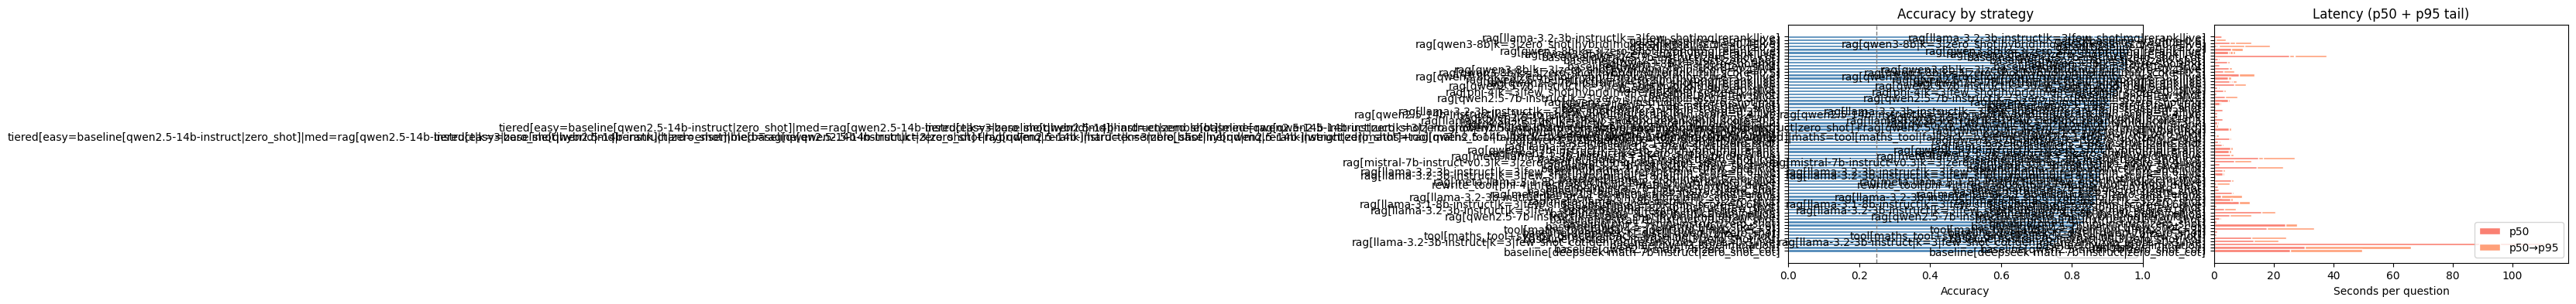

In [22]:
# Strategies on the x-axis; accuracy bars sorted descending. Speak louder than tables, plots do.
if leaderboard.empty:
    print('Leaderboard empty — nothing to plot yet.')
else:
    fig, (ax_acc, ax_lat) = plt.subplots(1, 2, figsize=(13, 4))

    df_sorted = leaderboard.sort_values('accuracy', ascending=False)
    ax_acc.barh(df_sorted['strategy'], df_sorted['accuracy'], color='steelblue', edgecolor='white')
    ax_acc.set_xlim(0, 1.0)
    ax_acc.set_xlabel('Accuracy')
    ax_acc.invert_yaxis()
    ax_acc.axvline(0.25, linestyle='--', color='grey', linewidth=1, label='random')
    ax_acc.set_title('Accuracy by strategy')
    ax_acc.legend(loc='lower right')

    ax_lat.barh(df_sorted['strategy'], df_sorted['latency_p50_s'], color='salmon', edgecolor='white',
                label='p50')
    ax_lat.barh(df_sorted['strategy'], df_sorted['latency_p95_s'] - df_sorted['latency_p50_s'],
                left=df_sorted['latency_p50_s'], color='lightsalmon', edgecolor='white',
                label='p50→p95')
    ax_lat.invert_yaxis()
    ax_lat.set_xlabel('Seconds per question')
    ax_lat.set_title('Latency (p50 + p95 tail)')
    ax_lat.legend(loc='lower right')

    plt.tight_layout()
    plt.show()

### 4.4 Per-category cross-strategy heatmap


/tmp/ipykernel_46859/3820664714.py:31: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


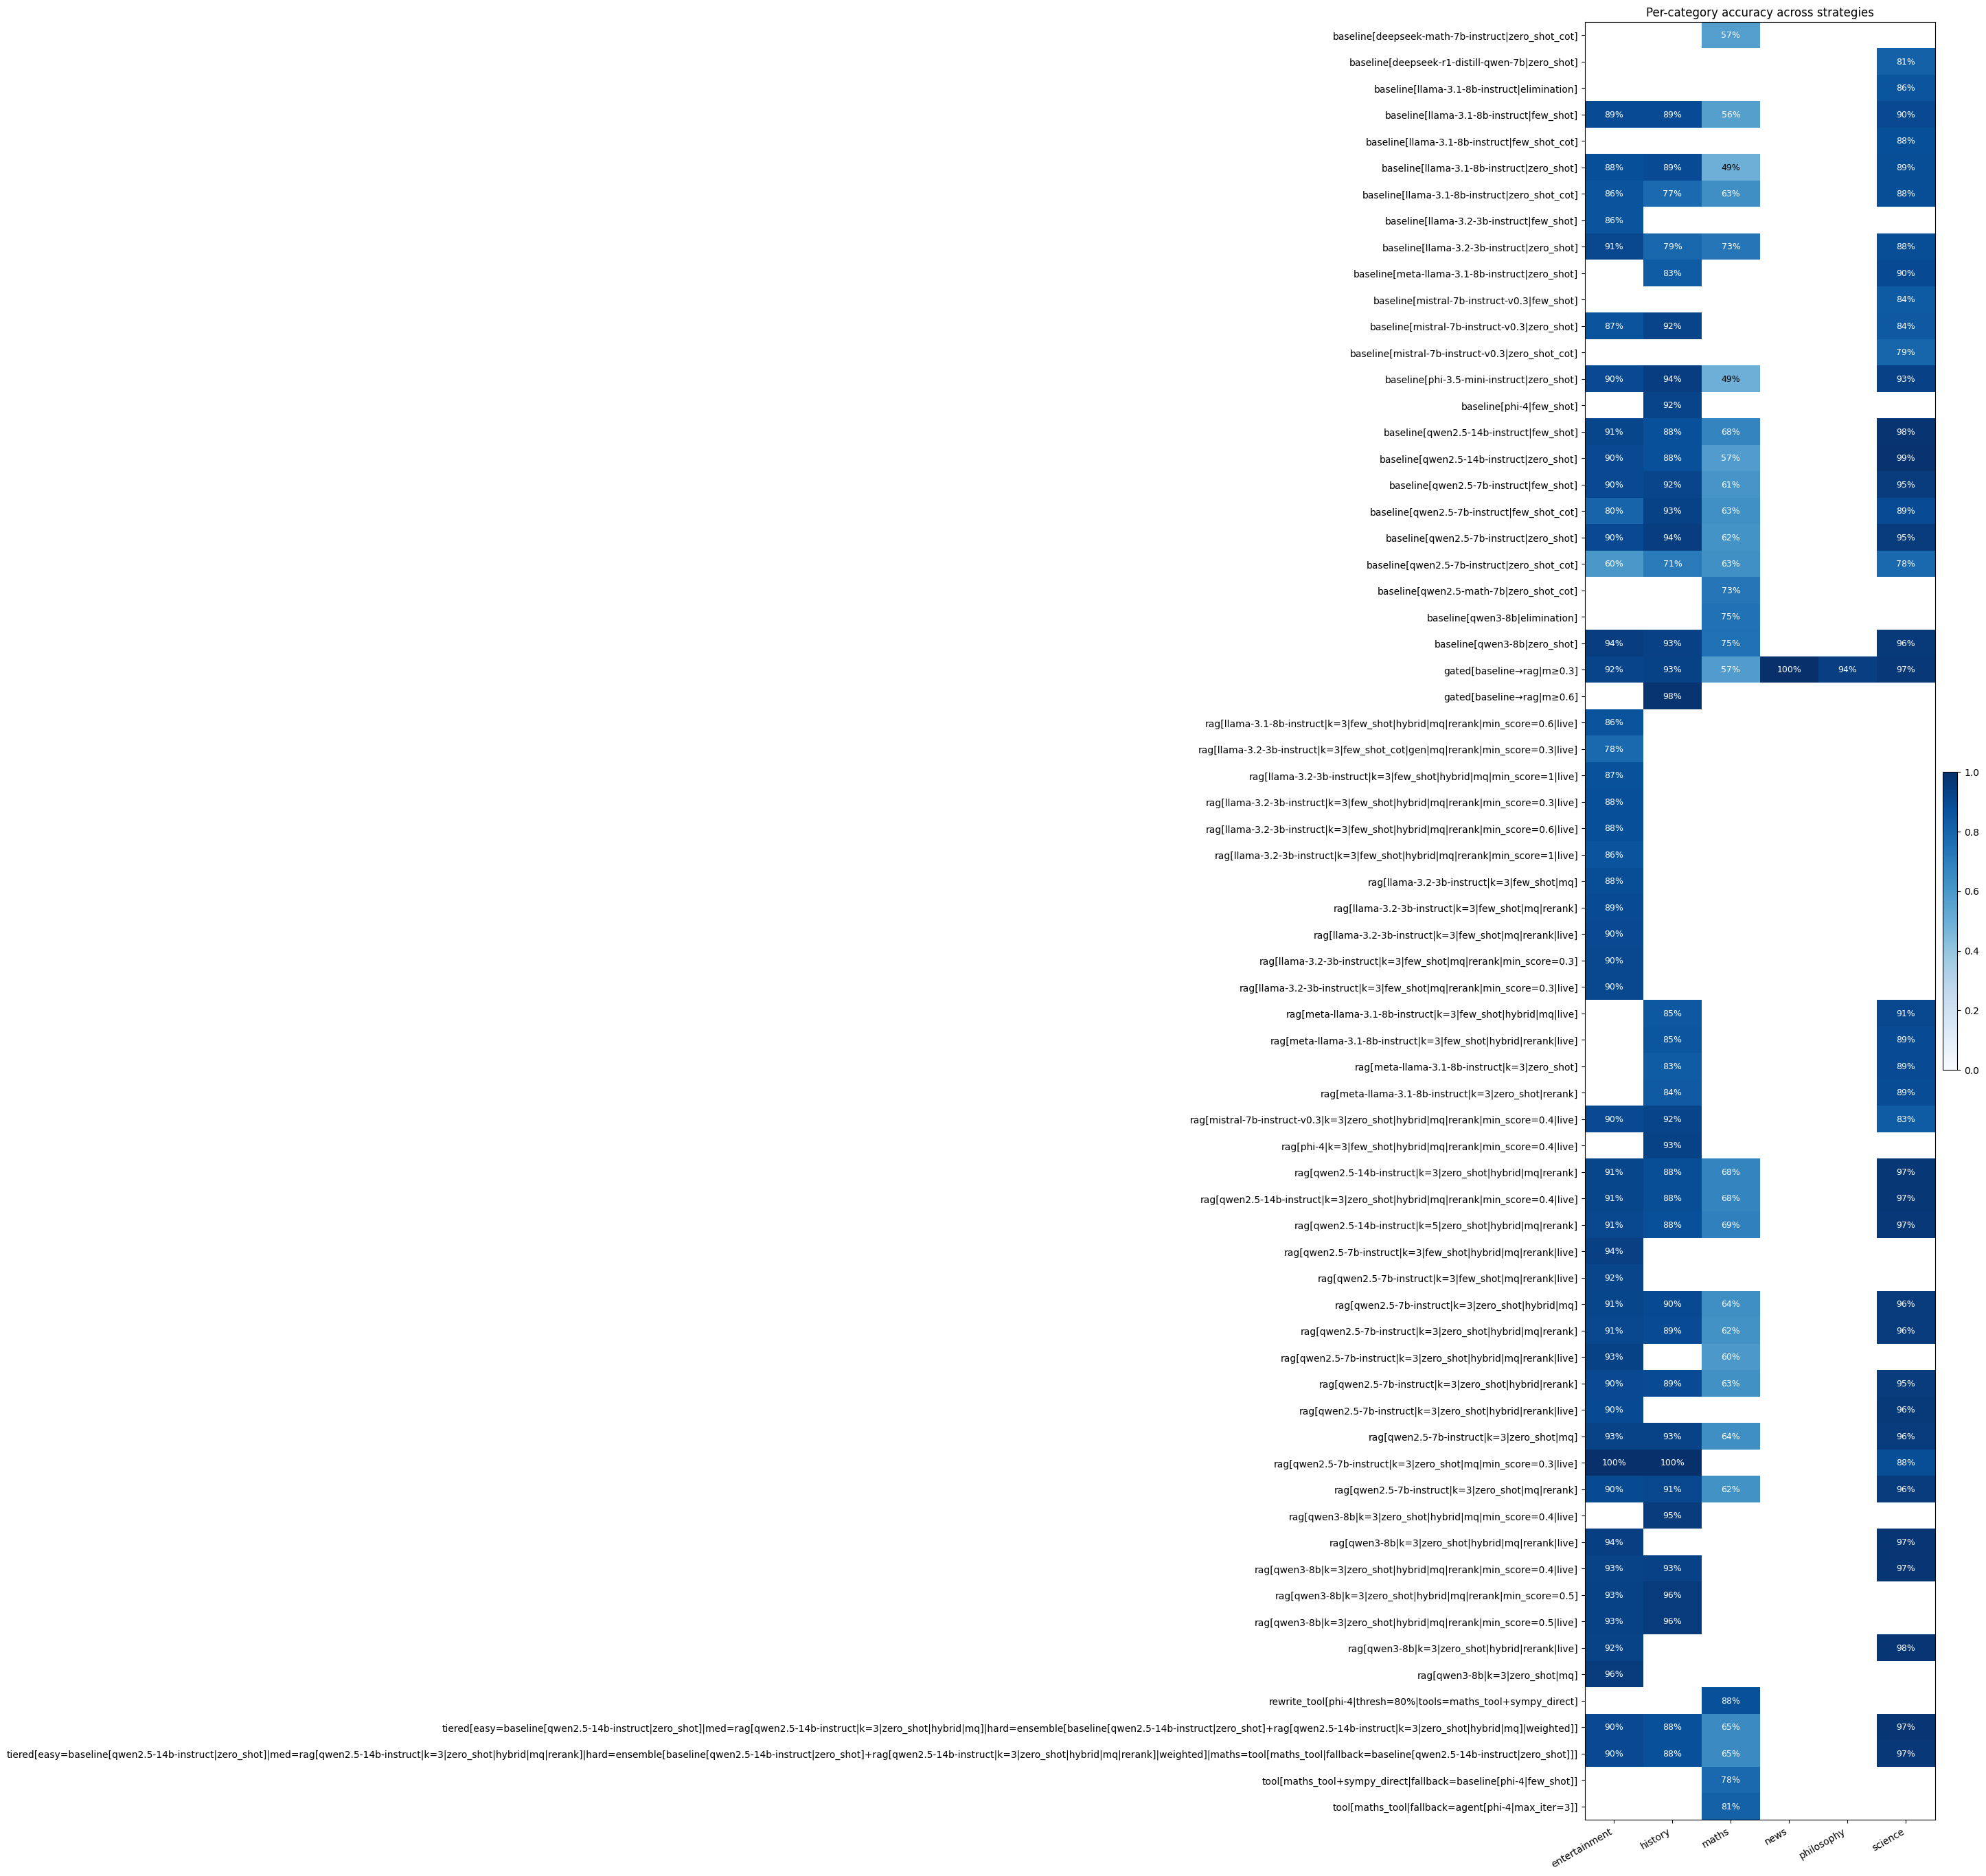

Saved → /content/PoliMillionaire/data/results/percategory_matrix.csv


In [23]:
# Reports include per-category accuracy. Heatmap, build it from disk we do.
def _load_report(p: Path) -> dict:
    return json.loads(p.read_text())

rows = []
for p in sorted(PATHS.eval_dir.glob('*.json')):
    data = _load_report(p)
    for cat, stats in data.get('by_category', {}).items():
        rows.append({
            'strategy': data['strategy_name'],
            'category': cat,
            'accuracy': stats.get('accuracy', float('nan')),
            'n':        stats.get('n', 0),
        })

if rows:
    heat = (pd.DataFrame(rows)
              .pivot_table(index='strategy', columns='category', values='accuracy'))
    fig, ax = plt.subplots(figsize=(7, max(2, 0.5 * len(heat))))
    im = ax.imshow(heat.values, vmin=0, vmax=1, cmap='Blues', aspect='auto')
    ax.set_xticks(range(len(heat.columns))); ax.set_xticklabels(heat.columns, rotation=30, ha='right')
    ax.set_yticks(range(len(heat.index)));   ax.set_yticklabels(heat.index)
    for i in range(heat.shape[0]):
        for j in range(heat.shape[1]):
            v = heat.values[i, j]
            if pd.notna(v):
                ax.text(j, i, f'{v:.0%}', ha='center', va='center',
                        color='white' if v > 0.55 else 'black', fontsize=9)
    fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
    ax.set_title('Per-category accuracy across strategies')
    plt.tight_layout()
    plt.show()
    save_results(heat.reset_index(), 'percategory_matrix')
else:
    print('No per-category data yet.')

---

## 5. Results & Discussion

_Fill this in after running Sections 2–4 on Colab. Keep every claim tied to a number in the plots/tables above — do not state results you have not measured._

### 5.1 Headline
- **Best overall configuration:** _strategy_ at **_xx.x%_** accuracy on the gold set (_N_ questions); reached level **_L_** / €_amount_ on the live ladder.
- **Reference points:** random = 25%; bare-LLM baseline = _xx.x%_.

### 5.2 Per-category findings
Winning strategy per category (mirrors the table in Section 1.3.1) and *why* it wins:

| Category | Best strategy | Accuracy | Why it works |
|---|---|---|---|
| Entertainment | _…_ | _…_ | _…_ |
| Ancient History & Politics | _…_ | _…_ | _…_ |
| Science & Nature | _…_ | _…_ | _…_ |
| Maths | _…_ | _…_ | _…_ |
| Philosophy & Psychology | _…_ | _…_ | _…_ |
| News | Confidence-gated + Guardian | _…_ | Date-aware retrieval supplies post-cutoff facts the base LLM cannot know |

### 5.3 Calibration & latency
- **Calibration (ECE):** _…_ — comment on over/under-confidence from the reliability diagram (Section 2.5).
- **Latency:** p50 _…s_ / p95 _…s_ per question, against the 25 s server budget (Section 4.3).

### 5.4 Limitations & future work
- _e.g. corpus-coverage gaps, reranker threshold calibration, structured sources (Wikidata) for Entertainment, …_
